# 项目：用逻辑回归预测某航空公司乘客满意度情况

## 分析目标

使用的数据集是某航空公司乘客满意度调查结果，用于分析哪些因素与乘客满意（或不满意）高度相关，并用训练数据构建机器学习模型，来预测测试数据中乘客的满意情况。

## 简介

数据集包括两个数据表：`airline_survey_test.csv`和`airline_survey_train.csv`。

`airline_survey_train.csv`记录了超过100000条航空公司乘客满意度的调查结果，可能有多种因素与乘客满意（不满意）有关，包括性别、客户类型、年龄、飞行目的、旅行舱、飞行距离等。

`airline_survey_test.csv`里的数据不在`airline_survey_train.csv`里，此文件可以被用于预测乘客是否满意。

`airline_survey_train.csv`每列的含义如下：
- Gender：乘客的性别（女性、男性）
- Customer Type：客户类型（忠诚客户、非忠诚客户）
- Age：乘客的年龄
- Type of Travel：乘客的飞行目的（个人旅行、商务旅行）
- Class：乘客乘坐飞机的旅行舱（Business - 商务舱、Eco - 经济舱、Eco-Plus - 舒适经济舱）
- Flight distance：这段旅程的飞行距离
- Inflight wifi service：机上无线网络服务的满意度（0：没有；1-5）
- Departure/Arrival time convenient：离港/抵达时间方便的满意度
- Ease of Online booking：在线预订的满意度
- Gate location：登机口位置满意度
- Food and drink：食品和饮料的满意度
- Satisfaction level of online boarding：在线登机的满意度
- Seat comfort：座椅舒适度的满意度
- Inflight entertainment：机上娱乐的满意度
- On-board service：机上服务满意度
- Leg room service：腿部空间满意度
- Baggage handling：行李处理的满意度
- Check-in service：登机服务满意度
- Inflight service：机上服务满意度
- Cleanliness：清洁度满意度
- Departure Delay in Minutes：出发时延迟的分钟数
- Arrival Delay in Minutes：抵达时延迟的分钟数
- Satisfaction：航空公司满意度（满意、中立或不满意）

`airline_survey_test.csv`每列的含义和上面相同。

## 读取数据

导入数据分析所需要的库。

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

我们计划先利用`airline_survey_train.csv`训练预测模型，因此读取数据方面，当前只需要导入`airline_survey_train.csv`。

通过Pandas的`read_csv`函数，将原始数据文件`airline_survey_train.csv`里的数据内容，解析为DataFrame并赋值给变量`original_airline_survey_train`。

In [2]:
original_airline_survey_train = pd.read_csv("airline_survey_train.csv")
original_airline_survey_train.head()

,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied


## 评估和清理数据

在这一部分中，我们将对在上一部分建立的`original_airline_survey_train`DataFrame所包含的数据进行评估和清理。

主要从两个方面进行：结构和内容，即整齐度和干净度。

数据的结构性问题指不符合“每个变量为一列，每个观察值为一行，每种类型的观察单位为一个表格”这三个标准；数据的内容性问题包括存在丢失数据、重复数据、无效数据等。

为了区分开经过清理的数据和原始的数据，我们创建新的变量`cleaned_airline_survey_train`，让它为`original_airline_survey_train`复制出的副本。我们之后的清理步骤都将被运用在`cleaned_airline_survey_train`上。

In [3]:
cleaned_airline_survey_train = original_airline_survey_train.copy()

### 数据整齐度

In [4]:
cleaned_airline_survey_train.head(10)

,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied
5,5,111157,Female,Loyal Customer,26,Personal Travel,Eco,1180,3,4,...,1,3,4,4,4,4,1,0,0.0,neutral or dissatisfied
6,6,82113,Male,Loyal Customer,47,Personal Travel,Eco,1276,2,4,...,2,3,3,4,3,5,2,9,23.0,neutral or dissatisfied
7,7,96462,Female,Loyal Customer,52,Business travel,Business,2035,4,3,...,5,5,5,5,4,5,4,4,0.0,satisfied
8,8,79485,Female,Loyal Customer,41,Business travel,Business,853,1,2,...,1,1,2,1,4,1,2,0,0.0,neutral or dissatisfied
9,9,65725,Male,disloyal Customer,20,Business travel,Eco,1061,3,3,...,2,2,3,4,4,3,2,0,0.0,neutral or dissatisfied


从头部的10行数据来看，数据符合“每个变量为一列，每个观察值为一行，每种类型的观察单位为一个表格”，因此不存在结构性问题。

### 数据干净度

接下来通过`info`，对数据内容进行大致了解。

In [5]:
cleaned_airline_survey_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103904 entries, 0 to 103903
Data columns (total 25 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Unnamed: 0                         103904 non-null  int64  
 1   id                                 103904 non-null  int64  
 2   Gender                             103904 non-null  object 
 3   Customer Type                      103904 non-null  object 
 4   Age                                103904 non-null  int64  
 5   Type of Travel                     103904 non-null  object 
 6   Class                              103904 non-null  object 
 7   Flight Distance                    103904 non-null  int64  
 8   Inflight wifi service              103904 non-null  int64  
 9   Departure/Arrival time convenient  103904 non-null  int64  
 10  Ease of Online booking             103904 non-null  int64  
 11  Gate location                      1039

从输出结果来看，`cleaned_airline_survey_train`共有103904条观察值，其中`Arrival Delay in Minutes`存在缺失值，将在后续进行评估和清理。

数据类型方面，`id`表示乘客ID，数据类型不应为数字，应为字符串，所以需要进行数据格式转换。

并且，我们已知`satisfaction`（是否满意）、`Gender`（性别）、`Customer Type`（乘客类型）、`Type of Travel`（乘客的飞行目的（个人旅行、商务旅行））、`Class`（乘客乘坐飞机的旅行舱（Business - 商务舱、Eco - 经济舱、Eco-Plus - 舒适经济舱））都是分类数据，可以把数据类型都转换为Category。

In [6]:
cleaned_airline_survey_train['id'] = cleaned_airline_survey_train['id'].astype('str')

In [7]:
cleaned_airline_survey_train['satisfaction'] = cleaned_airline_survey_train['satisfaction'].astype('category')
cleaned_airline_survey_train['Gender'] = cleaned_airline_survey_train['Gender'].astype('category')
cleaned_airline_survey_train['Customer Type'] = cleaned_airline_survey_train['Customer Type'].astype('category')
cleaned_airline_survey_train['Type of Travel'] = cleaned_airline_survey_train['Type of Travel'].astype('category')
cleaned_airline_survey_train['Class'] = cleaned_airline_survey_train['Class'].astype('category')

In [8]:
cleaned_airline_survey_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103904 entries, 0 to 103903
Data columns (total 25 columns):
 #   Column                             Non-Null Count   Dtype   
---  ------                             --------------   -----   
 0   Unnamed: 0                         103904 non-null  int64   
 1   id                                 103904 non-null  object  
 2   Gender                             103904 non-null  category
 3   Customer Type                      103904 non-null  category
 4   Age                                103904 non-null  int64   
 5   Type of Travel                     103904 non-null  category
 6   Class                              103904 non-null  category
 7   Flight Distance                    103904 non-null  int64   
 8   Inflight wifi service              103904 non-null  int64   
 9   Departure/Arrival time convenient  103904 non-null  int64   
 10  Ease of Online booking             103904 non-null  int64   
 11  Gate location             

#### 处理缺失数据

从`info`方法的输出结果来看，在`cleaned_airline_survey_train`中，`Arrival Delay in Minutes`变量存在缺失值。

In [9]:
cleaned_airline_survey_train[cleaned_airline_survey_train['Arrival Delay in Minutes'].isna()]

,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
213,213,49608,Female,Loyal Customer,38,Business travel,Eco,109,5,3,...,5,5,2,4,1,1,5,31,NaN,satisfied
1124,1124,73442,Male,Loyal Customer,53,Personal Travel,Eco,1012,3,2,...,4,4,4,4,3,3,4,38,NaN,neutral or dissatisfied
1529,1529,71178,Male,Loyal Customer,39,Business travel,Business,733,2,5,...,2,2,2,2,2,2,3,11,NaN,neutral or dissatisfied
2004,2004,72940,Female,disloyal Customer,26,Business travel,Business,1035,3,3,...,2,3,3,4,5,5,2,41,NaN,neutral or dissatisfied
2108,2108,116374,Female,Loyal Customer,24,Personal Travel,Eco,417,2,1,...,5,1,4,2,1,2,5,1,NaN,neutral or dissatisfied
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
102067,102067,36729,Male,Loyal Customer,49,Personal Travel,Eco Plus,1249,2,5,...,3,4,5,4,3,4,3,230,NaN,neutral or dissatisfied
102384,102384,71241,Male,Loyal Customer,58,Business travel,Eco,733,3,3,...,3,3,1,2,4,2,3,55,NaN,neutral or dissatisfied
102552,102552,27684,Female,disloyal Customer,29,Business travel,Eco,1107,2,1,...,5,4,1,5,5,3,5,0,NaN,neutral or dissatisfied
102960,102960,36787,Male,Loyal Customer,58,Business travel,Eco,1088,4,4,...,5,1,5,5,5,3,5,0,NaN,satisfied


In [10]:
cleaned_airline_survey_train['Arrival Delay in Minutes'].isna().sum()

np.int64(310)

有310条观察值的`Arrival Delay in Minutes`抵达时延迟的分钟数变量缺失。由于这些观察值其它变量仍然能为分析提供价值，我们最好保留这些行。

但由于我们后面需要用到的逻辑回归函数`Logit`不允许数据中包含缺失值，所以用乘客抵达时延迟的分钟数平均值对缺失值进行填充。

In [11]:
average_Arrival_Delay_in_Minutes = cleaned_airline_survey_train['Arrival Delay in Minutes'].mean()
cleaned_airline_survey_train['Arrival Delay in Minutes'] = cleaned_airline_survey_train['Arrival Delay in Minutes'].fillna(average_Arrival_Delay_in_Minutes)
cleaned_airline_survey_train['Arrival Delay in Minutes'].isna().sum()
#看一下平均延迟时间
print(average_Arrival_Delay_in_Minutes)

15.178678301832152


In [12]:
cleaned_airline_survey_train.head(10)

,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied
5,5,111157,Female,Loyal Customer,26,Personal Travel,Eco,1180,3,4,...,1,3,4,4,4,4,1,0,0.0,neutral or dissatisfied
6,6,82113,Male,Loyal Customer,47,Personal Travel,Eco,1276,2,4,...,2,3,3,4,3,5,2,9,23.0,neutral or dissatisfied
7,7,96462,Female,Loyal Customer,52,Business travel,Business,2035,4,3,...,5,5,5,5,4,5,4,4,0.0,satisfied
8,8,79485,Female,Loyal Customer,41,Business travel,Business,853,1,2,...,1,1,2,1,4,1,2,0,0.0,neutral or dissatisfied
9,9,65725,Male,disloyal Customer,20,Business travel,Eco,1061,3,3,...,2,2,3,4,4,3,2,0,0.0,neutral or dissatisfied


#### 处理重复数据

根据数据变量的含义以及内容来看，`id`是乘客的唯一标识符，不应该存在重复，因此查看是否存在重复值。

In [13]:
cleaned_airline_survey_train["id"].duplicated().sum()

np.int64(0)

输出结果为0，说明不存在重复值。

#### 处理不一致数据

不一致数据可能存在于所有分类变量中，我们要查看是否存在不同值实际指代同一目标的情况。

In [14]:
print(cleaned_airline_survey_train["Gender"].value_counts())
print(cleaned_airline_survey_train["Customer Type"].value_counts())
print(cleaned_airline_survey_train["Type of Travel"].value_counts())
print(cleaned_airline_survey_train["Class"].value_counts())
print(cleaned_airline_survey_train["Inflight wifi service"].value_counts())
print(cleaned_airline_survey_train["Departure/Arrival time convenient"].value_counts())
print(cleaned_airline_survey_train["Ease of Online booking"].value_counts())
print(cleaned_airline_survey_train["Gate location"].value_counts())
print(cleaned_airline_survey_train["Food and drink"].value_counts())
print(cleaned_airline_survey_train["Online boarding"].value_counts())
print(cleaned_airline_survey_train["Seat comfort"].value_counts())
print(cleaned_airline_survey_train["Inflight entertainment"].value_counts())
print(cleaned_airline_survey_train["On-board service"].value_counts())
print(cleaned_airline_survey_train["Leg room service"].value_counts())
print(cleaned_airline_survey_train["Baggage handling"].value_counts())
print(cleaned_airline_survey_train["Checkin service"].value_counts())
print(cleaned_airline_survey_train["Inflight service"].value_counts())
print(cleaned_airline_survey_train["Cleanliness"].value_counts())
print(cleaned_airline_survey_train["satisfaction"].value_counts())

Gender
Female    52727
Male      51177
Name: count, dtype: int64
Customer Type
Loyal Customer       84923
disloyal Customer    18981
Name: count, dtype: int64
Type of Travel
Business travel    71655
Personal Travel    32249
Name: count, dtype: int64
Class
Business    49665
Eco         46745
Eco Plus     7494
Name: count, dtype: int64
Inflight wifi service
3    25868
2    25830
4    19794
1    17840
5    11469
0     3103
Name: count, dtype: int64
Departure/Arrival time convenient
4    25546
5    22403
3    17966
2    17191
1    15498
0     5300
Name: count, dtype: int64
Ease of Online booking
3    24449
2    24021
4    19571
1    17525
5    13851
0     4487
Name: count, dtype: int64
Gate location
3    28577
4    24426
2    19459
1    17562
5    13879
0        1
Name: count, dtype: int64
Food and drink
4    24359
5    22313
3    22300
2    21988
1    12837
0      107
Name: count, dtype: int64
Online boarding
4    30762
3    21804
5    20713
2    17505
1    10692
0     2428
Name: count, d

从以上输出结果来看，均不存在不一致数据。

#### 处理无效或错误数据

可以通过DataFrame的`describe`方法，对数值统计信息进行快速了解。

In [15]:
cleaned_airline_survey_train.describe()

,Unnamed: 0,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
count,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000
mean,51951.500000,39.379706,1189.448375,2.729683,3.060296,2.756901,2.976883,3.202129,3.250375,3.439396,3.358158,3.382363,3.351055,3.631833,3.304290,3.640428,3.286351,14.815618,15.178678
std,29994.645522,15.114964,997.147281,1.327829,1.525075,1.398929,1.277621,1.329533,1.349509,1.319088,1.332991,1.288354,1.315605,1.180903,1.265396,1.175663,1.312273,38.230901,38.640909
min,0.000000,7.000000,31.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,25975.750000,27.000000,414.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000,3.000000,3.000000,2.000000,0.000000,0.000000
50%,51951.500000,40.000000,843.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,4.000000,4.000000,4.000000,4.000000,4.000000,3.000000,4.000000,3.000000,0.000000,0.000000
75%,77927.250000,51.000000,1743.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,5.000000,4.000000,4.000000,4.000000,5.000000,4.000000,5.000000,4.000000,12.000000,13.000000
max,103903.000000,85.000000,4983.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,1592.000000,1584.000000


乘客年龄平均为39岁左右，最大值为85岁，最小值为7岁。
飞行举例数值范围正常。
满意度相关变量也数值正常，除了`Baggage handling`（行李处理的满意度）为1-5，其它都是0-5。
发现出发时延迟的分钟数和抵达时延迟的分钟数的最大值分别是1592分子和1584分子，这可能不正常。

这里通过排序后取头部的方式，打印出出发时延迟的分钟数和抵达时延迟的分钟数的最大的10个值进行观察：

In [16]:
top10_departure_delay = cleaned_airline_survey_train['Departure Delay in Minutes'].sort_values(ascending=False).head(10)
top10_arrival_delay = cleaned_airline_survey_train['Arrival Delay in Minutes'].sort_values(ascending=False).head(10)
print(top10_departure_delay)
print(top10_arrival_delay)

83741    1592
6744     1305
61310    1017
72206     978
80182     933
61287     930
61528     921
27732     859
51860     853
37096     750
Name: Departure Delay in Minutes, dtype: int64
83741    1584.0
6744     1280.0
61310    1011.0
72206     970.0
61287     952.0
61528     924.0
80182     920.0
27732     860.0
51860     823.0
37096     729.0
Name: Arrival Delay in Minutes, dtype: float64


通过观察发现，最大的几个出发延迟和抵达延迟成一定对应关系，可以推测是由于某些问题导致航班长时间的耽搁，所以这里选择保留这些观察值。

由于第一列是排序编号，在这里与DataFrame的索引重复，所以可以将其删除掉。

In [17]:
cleaned_airline_survey_train.drop('Unnamed: 0', axis=1, inplace=True)

## 整理数据

对数据的整理，与分析方向紧密相关。此次数据分析目标是，根据乘客的相关信息，预测乘客的满意或不满意。
观察可知，每一个变量都具有一定的独立性，所以没有必要进行变量合并等数据整理操作。

In [18]:
cleaned_airline_survey_train.head()

,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,3,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,3,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied


## 探索数据

在着手逻辑回归分析之前，我们可以先借助数据可视化，探索数值变量的分布，以及与乘客是否满意相关性的变量，为后续的进一步分析提供方向。

In [19]:
# 设置图表色盘为"pastel"
sns.set_palette("pastel")

In [20]:
# 设置图表尺寸
plt.rcParams["figure.figsize"] = [7.00, 3.50]
plt.rcParams["figure.autolayout"] = True

### 满意比例

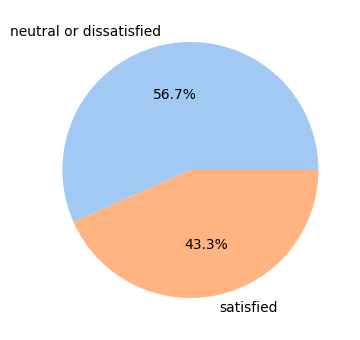

In [21]:
satisfaction_count = cleaned_airline_survey_train['satisfaction'].value_counts()
satisfaction_label = satisfaction_count.index
plt.pie(satisfaction_count, labels=satisfaction_label, autopct='%.1f%%')
plt.show()

从以上饼图来看，航空公司乘客中满意的乘客数量小于中立或不满意的乘客数量，比例约为3:4。

### 乘客年龄

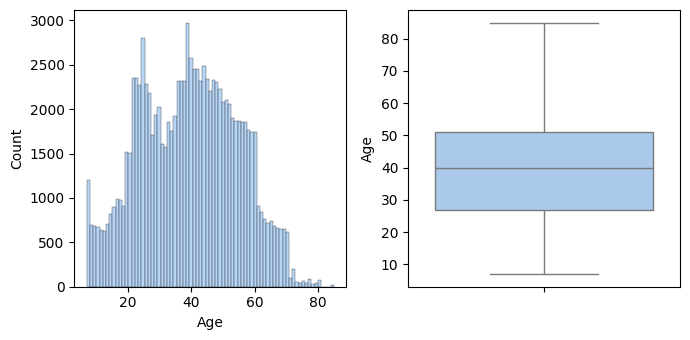

In [22]:
figure, axes = plt.subplots(1, 2)
sns.histplot(cleaned_airline_survey_train, x='Age', ax=axes[0])
sns.boxplot(cleaned_airline_survey_train, y='Age', ax=axes[1])
plt.show()

大多数乘客年龄位于25岁到50岁之间，但也有不少老年乘客以及儿童。

### 乘客年龄与是否满意

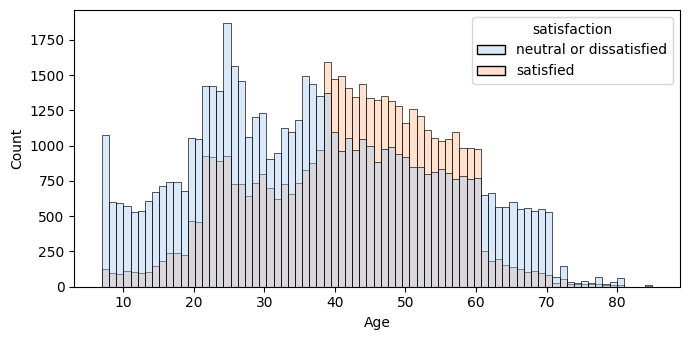

In [23]:
sns.histplot(cleaned_airline_survey_train, x='Age', hue='satisfaction', alpha=0.4)
plt.show()

从乘客年龄直方图来看，10-40岁、60-80岁中立或不满意的乘客较多，而40-60岁中满意的乘客数量较多。

### 性别与是否满意的关系

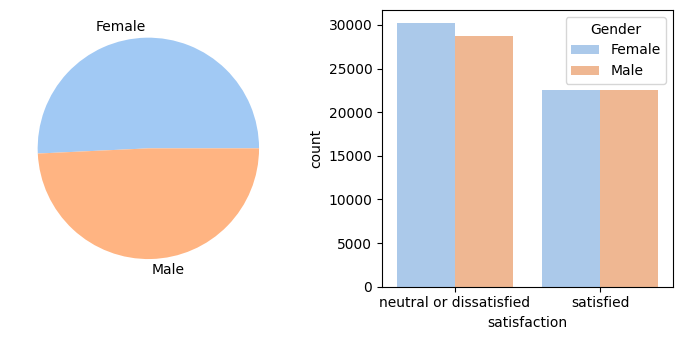

In [24]:
figure, axes = plt.subplots(1, 2)
gender_count = cleaned_airline_survey_train['Gender'].value_counts()
gender_label = gender_count.index
axes[0].pie(gender_count, labels=gender_label)
sns.countplot(cleaned_airline_survey_train, x='satisfaction', hue='Gender', ax=axes[1])
plt.show()

从是否满意与性别之间的柱状图来看，男女中满意的乘客比例基本相同，性别与是否满意关系不大。

### 飞机的旅行舱等级与是否满意的关系

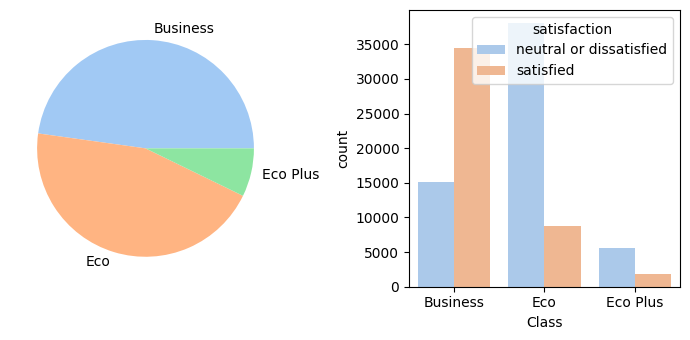

In [25]:
figure, axes = plt.subplots(1, 2)
class_count = cleaned_airline_survey_train['Class'].value_counts()
class_label = class_count.index
axes[0].pie(class_count, labels=class_label)
sns.countplot(cleaned_airline_survey_train, x='Class', hue='satisfaction', ax=axes[1])
plt.show()

从是否满意与飞机旅行舱等级之间的柱状图来看，商务舱乘客中满意比例较大，经济舱和舒适经济舱乘客中满意比例较小。

### 客户类型与是否满意的关系

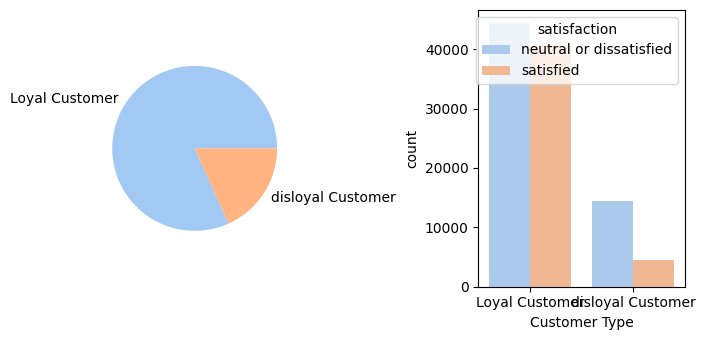

In [26]:
figure, axes = plt.subplots(1, 2)
customer_type_count = cleaned_airline_survey_train['Customer Type'].value_counts()
customer_type_label = customer_type_count.index
axes[0].pie(customer_type_count, labels=customer_type_label)
sns.countplot(cleaned_airline_survey_train, x='Customer Type', hue='satisfaction', ax=axes[1])
plt.show()

从是否满意与客户类型之间的柱状图来看，忠诚客户的满意比例要比非忠诚客户的满意比例高。

### 飞行目的与是否满意的关系

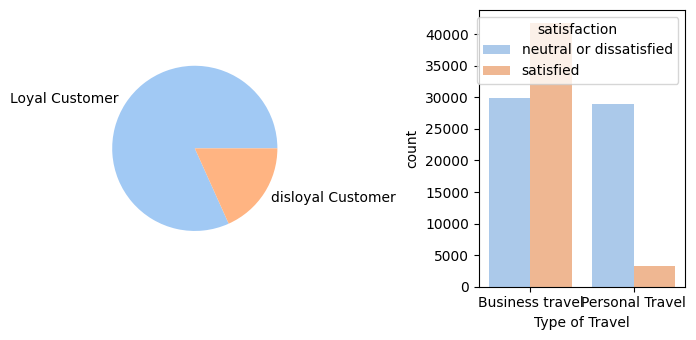

In [27]:
figure, axes = plt.subplots(1, 2)
type_of_travel_count = cleaned_airline_survey_train['Customer Type'].value_counts()
type_of_travel_label = type_of_travel_count.index
axes[0].pie(type_of_travel_count, labels=type_of_travel_label)
sns.countplot(cleaned_airline_survey_train, x='Type of Travel', hue='satisfaction', ax=axes[1])
plt.show()

从是否满意与乘客飞行目的之间的柱状图来看，商务旅行的乘客满意比例远高于个人旅行的乘客满意比例。

## 分析数据

在分析步骤中，我们将利用以上清理后到的数据，进行逻辑回归分析，目标是得到一个可以根据航空公司的乘客各个属性，对乘客满意情况进行预测的数学模型。

我们先引入做逻辑回归所需的模块。

In [28]:
import statsmodels.api as sm

然后可以创建一个新的DataFrame`lr_airline_survey_train`，让它作为我们进逻辑性回归分析所用的数据。lr为Linear Regression（线性回归）的缩写，这是机器学习中最基础和核心的监督学习算法之一，用于建立因变量和一个或多个自变量之间的线性关系模型。

和`cleaned_airline_survey_train`区分开的原因是，我们在进行回归分析前，还可能需要对数据进行一些准备，比如引入虚拟变量，这些都可以在`lr_airline_survey_train`上执行。

In [29]:
lr_airline_survey_train = cleaned_airline_survey_train.copy()
lr_airline_survey_train.head()

,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,3,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,3,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied


移除大概率不会影响乘客满意概率的变量：id

In [30]:
lr_airline_survey_train = lr_airline_survey_train.drop(['id'], axis=1)
lr_airline_survey_train.head()

,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,3,1,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,Male,disloyal Customer,25,Business travel,Business,235,3,2,3,3,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,Female,Loyal Customer,26,Business travel,Business,1142,2,2,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,Female,Loyal Customer,25,Business travel,Business,562,2,5,5,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,Male,Loyal Customer,61,Business travel,Business,214,3,3,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied


数据里还存在分类变量，无法直接建立逻辑回归模型。我们需要引入虚拟变量，也就是用0和1分别表示是否属于该类别。

In [31]:
lr_airline_survey_train  = pd.get_dummies(lr_airline_survey_train , drop_first=True, columns=['Gender', 'Customer Type', 'Type of Travel', 'Class', 'satisfaction'], dtype=int)
lr_airline_survey_train.head()

,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,...,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,Gender_Male,Customer Type_disloyal Customer,Type of Travel_Personal Travel,Class_Eco,Class_Eco Plus,satisfaction_satisfied
0,13,460,3,4,3,1,5,3,5,5,...,5,5,25,18.0,1,0,1,0,1,0
1,25,235,3,2,3,3,1,3,1,1,...,4,1,1,6.0,1,1,0,0,0,0
2,26,1142,2,2,2,2,5,5,5,5,...,4,5,0,0.0,0,0,0,0,0,1
3,25,562,2,5,5,5,2,2,2,2,...,4,2,11,9.0,0,0,0,0,0,0
4,61,214,3,3,3,3,4,5,5,3,...,3,3,0,0.0,1,0,0,0,0,1


接下来，我们要把因变量和自变量划分出来。

在这里因变量是`satisfaction_satisfied`变量，因为我们进行逻辑回归的目的，是根据其它可能对因变量乘客满意概率有影响的变量，来预测是否满意的情况。

In [32]:
y = lr_airline_survey_train['satisfaction_satisfied']

把除`satisfaction_satisfied`之外的先纳入自变量，但需要查看它们之间的相关性。如果其中有些变量之间相关性很高，会导致共线性。

In [33]:
X = lr_airline_survey_train.drop(['satisfaction_satisfied'], axis=1)
X.corr()

,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,...,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,Gender_Male,Customer Type_disloyal Customer,Type of Travel_Personal Travel,Class_Eco,Class_Eco Plus
Age,1.000000,0.099461,0.017859,0.038125,0.024842,-0.001330,0.023000,0.208939,0.160277,0.076444,...,0.035482,-0.049427,0.053611,-0.010152,-0.012127,0.008928,-0.281674,-0.048524,-0.132551,-0.013376
Flight Distance,0.099461,1.000000,0.007131,-0.020043,0.065717,0.004793,0.056994,0.214869,0.157333,0.128740,...,0.073072,0.057540,0.093149,0.002158,-0.002423,0.005828,-0.225200,-0.267344,-0.404493,-0.123674
Inflight wifi service,0.017859,0.007131,1.000000,0.343845,0.715856,0.336248,0.134718,0.456970,0.122658,0.209321,...,0.043193,0.110441,0.132698,-0.017402,-0.019067,0.008974,-0.007543,-0.105085,-0.037197,0.008034
Departure/Arrival time convenient,0.038125,-0.020043,0.343845,1.000000,0.436961,0.444757,0.004906,0.070119,0.011344,-0.004861,...,0.093333,0.073318,0.014292,0.001005,-0.000863,0.009142,-0.206869,0.259763,0.082321,0.028740
Ease of Online booking,0.024842,0.065717,0.715856,0.436961,1.000000,0.458655,0.031873,0.404074,0.030014,0.047032,...,0.011081,0.035272,0.016179,-0.006371,-0.007972,0.006951,-0.019509,-0.133511,-0.098039,-0.018914
Gate location,-0.001330,0.004793,0.336248,0.444757,0.458655,1.000000,-0.001159,0.001688,0.003669,0.003517,...,-0.035427,0.001681,-0.003830,0.005467,0.005136,0.000333,0.006078,-0.030700,-0.003488,-0.002031
Food and drink,0.023000,0.056994,0.134718,0.004906,0.031873,-0.001159,1.000000,0.234468,0.574556,0.622512,...,0.087299,0.033993,0.657760,-0.029926,-0.032472,0.005772,-0.059454,-0.063439,-0.078801,-0.016671
Online boarding,0.208939,0.214869,0.456970,0.070119,0.404074,0.001688,0.234468,1.000000,0.420211,0.285066,...,0.204462,0.074573,0.331517,-0.018982,-0.021915,-0.042260,-0.189262,-0.224803,-0.293103,-0.074608
Seat comfort,0.160277,0.157333,0.122658,0.011344,0.030014,0.003669,0.574556,0.420211,1.000000,0.610590,...,0.191854,0.069218,0.678534,-0.027898,-0.029851,-0.026502,-0.159484,-0.124399,-0.206054,-0.054034
Inflight entertainment,0.076444,0.128740,0.209321,-0.004861,0.047032,0.003517,0.622512,0.285066,0.610590,1.000000,...,0.120867,0.404855,0.691815,-0.027489,-0.030658,0.006117,-0.109930,-0.148199,-0.176323,-0.045271


一般我们认为，当相关系数的绝对值大于0.8的时候，可能导致严重共线性，所以我们检查的时候，找绝对值大于0.8的值即可。

In [34]:
X.corr().abs() > 0.8

,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,...,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,Gender_Male,Customer Type_disloyal Customer,Type of Travel_Personal Travel,Class_Eco,Class_Eco Plus
Age,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
Flight Distance,False,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
Inflight wifi service,False,False,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
Departure/Arrival time convenient,False,False,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
Ease of Online booking,False,False,False,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
Gate location,False,False,False,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
Food and drink,False,False,False,False,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
Online boarding,False,False,False,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
Seat comfort,False,False,False,False,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
Inflight entertainment,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False


从以上输出来看，各变量之间不存在强关联的问题。

接下来，给模型的线性方程添加截距。

In [35]:
X = sm.add_constant(X)

In [36]:
lr_airline_survey_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103904 entries, 0 to 103903
Data columns (total 24 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Age                                103904 non-null  int64  
 1   Flight Distance                    103904 non-null  int64  
 2   Inflight wifi service              103904 non-null  int64  
 3   Departure/Arrival time convenient  103904 non-null  int64  
 4   Ease of Online booking             103904 non-null  int64  
 5   Gate location                      103904 non-null  int64  
 6   Food and drink                     103904 non-null  int64  
 7   Online boarding                    103904 non-null  int64  
 8   Seat comfort                       103904 non-null  int64  
 9   Inflight entertainment             103904 non-null  int64  
 10  On-board service                   103904 non-null  int64  
 11  Leg room service                   1039

下一步就可以调用`Logit`函数，利用最大似然优化来得到逻辑回归模型的参数值，并输出总结信息。

In [37]:
model = sm.Logit(y, X).fit()
model.summary()

Optimization terminated successfully.
         Current function value: 0.333885
         Iterations 7


<class 'statsmodels.iolib.summary.Summary'>
"""
                             Logit Regression Results                             
==================================================================================
Dep. Variable:     satisfaction_satisfied   No. Observations:               103904
Model:                              Logit   Df Residuals:                   103880
Method:                               MLE   Df Model:                           23
Date:                    Fri, 06 Mar 2026   Pseudo R-squ.:                  0.5120
Time:                            11:38:56   Log-Likelihood:                -34692.
converged:                           True   LL-Null:                       -71094.
Covariance Type:                nonrobust   LLR p-value:                     0.000
=====================================================================================================
                                        coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
const                                -5.8305      0.075    -77.742      0.000      -5.977      -5.683
Age                                  -0.0083      0.001    -11.676      0.000      -0.010      -0.007
Flight Distance                   -1.711e-05   1.13e-05     -1.514      0.130   -3.93e-05    5.04e-06
Inflight wifi service                 0.3948      0.011     34.457      0.000       0.372       0.417
Departure/Arrival time convenient    -0.1248      0.008    -15.208      0.000      -0.141      -0.109
Ease of Online booking               -0.1429      0.011    -12.619      0.000      -0.165      -0.121
Gate location                         0.0293      0.009      3.196      0.001       0.011       0.047
Food and drink                       -0.0276      0.011     -2.590      0.010      -0.049      -0.007
Online boarding                       0.6124      0.010     59.854      0.000       0.592       0.632
Seat comfort                          0.0668      0.011      5.984      0.000       0.045       0.089
Inflight entertainment                0.0639      0.014      4.486      0.000       0.036       0.092
On-board service                      0.3017      0.010     29.644      0.000       0.282       0.322
Leg room service                      0.2529      0.009     29.675      0.000       0.236       0.270
Baggage handling                      0.1342      0.011     11.749      0.000       0.112       0.157
Checkin service                       0.3237      0.009     37.849      0.000       0.307       0.341
Inflight service                      0.1201      0.012      9.984      0.000       0.097       0.144
Cleanliness                           0.2231      0.012     18.466      0.000       0.199       0.247
Departure Delay in Minutes            0.0042      0.001      4.546      0.000       0.002       0.006
Arrival Delay in Minutes             -0.0089      0.001     -9.680      0.000      -0.011      -0.007
Gender_Male                           0.0406      0.019      2.088      0.037       0.002       0.079
Customer Type_disloyal Customer      -2.0360      0.030    -68.091      0.000      -2.095      -1.977
Type of Travel_Personal Travel       -2.7204      0.031    -86.612      0.000      -2.782      -2.659
Class_Eco                            -0.7365      0.026    -28.738      0.000      -0.787      -0.686
Class_Eco Plus                       -0.8520      0.041    -20.550      0.000      -0.933      -0.771
=====================================================================================================
"""

当我们把显著区间设定为0.03时，以上结果的P值可以看出，模型认为飞行距离和性别对乘客满意概率没有显著性影响。因此可以把这个变量移除后，再次建立逻辑回归模型。

In [38]:
X = X.drop(['Gender_Male', 'Flight Distance'], axis=1)
model = sm.Logit(y, X).fit()
model.summary()

Optimization terminated successfully.
         Current function value: 0.333917
         Iterations 7


<class 'statsmodels.iolib.summary.Summary'>
"""
                             Logit Regression Results                             
==================================================================================
Dep. Variable:     satisfaction_satisfied   No. Observations:               103904
Model:                              Logit   Df Residuals:                   103882
Method:                               MLE   Df Model:                           21
Date:                    Fri, 06 Mar 2026   Pseudo R-squ.:                  0.5120
Time:                            11:38:57   Log-Likelihood:                -34695.
converged:                           True   LL-Null:                       -71094.
Covariance Type:                nonrobust   LLR p-value:                     0.000
=====================================================================================================
                                        coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
const                                -5.8420      0.071    -81.906      0.000      -5.982      -5.702
Age                                  -0.0082      0.001    -11.612      0.000      -0.010      -0.007
Inflight wifi service                 0.3962      0.011     34.637      0.000       0.374       0.419
Departure/Arrival time convenient    -0.1252      0.008    -15.259      0.000      -0.141      -0.109
Ease of Online booking               -0.1429      0.011    -12.622      0.000      -0.165      -0.121
Gate location                         0.0292      0.009      3.194      0.001       0.011       0.047
Food and drink                       -0.0266      0.011     -2.501      0.012      -0.048      -0.006
Online boarding                       0.6112      0.010     59.806      0.000       0.591       0.631
Seat comfort                          0.0660      0.011      5.913      0.000       0.044       0.088
Inflight entertainment                0.0628      0.014      4.411      0.000       0.035       0.091
On-board service                      0.3010      0.010     29.590      0.000       0.281       0.321
Leg room service                      0.2527      0.009     29.669      0.000       0.236       0.269
Baggage handling                      0.1349      0.011     11.816      0.000       0.112       0.157
Checkin service                       0.3237      0.009     37.854      0.000       0.307       0.341
Inflight service                      0.1207      0.012     10.040      0.000       0.097       0.144
Cleanliness                           0.2240      0.012     18.553      0.000       0.200       0.248
Departure Delay in Minutes            0.0042      0.001      4.551      0.000       0.002       0.006
Arrival Delay in Minutes             -0.0089      0.001     -9.687      0.000      -0.011      -0.007
Customer Type_disloyal Customer      -2.0263      0.029    -70.302      0.000      -2.083      -1.970
Type of Travel_Personal Travel       -2.7157      0.031    -87.066      0.000      -2.777      -2.655
Class_Eco                            -0.7250      0.024    -29.782      0.000      -0.773      -0.677
Class_Eco Plus                       -0.8390      0.040    -20.822      0.000      -0.918      -0.760
=====================================================================================================
"""

逻辑回归模型预测以下因素的增加（或存在）会极大地降低满意概率：客户类型为非忠诚客户、旅行目的是个人旅行、旅行舱为经济舱或舒适经济舱。

要理解各个各个自变量系数的实际含义，我们需要计算自然常数的次方。

In [39]:
# Online boarding
np.exp(0.6112)

np.float64(1.8426412421009857)

以上结果说明，线上值机满意度每增加1，满意概率提高约84%左右。

In [40]:
# Inflight wifi service
np.exp(0.3962)

np.float64(1.4861665211342676)

以上结果说明，机上无线网络服务的满意度每增加1，满意概率提高49%左右。

In [41]:
# Type of Travel_Personal Travel	
np.exp(-2.7157)

np.float64(0.06615862575639771)

以上结果说明，乘客的飞行目的如果是个人旅行的话，满意概率比商务旅行低94%左右。

In [42]:
np.exp(0.3)

np.float64(1.3498588075760032)

根据模型参数值，我们总结：
- 机上无线网络服务、在线值机、机上服务、登机服务、腿部空间、清洁度等的满意度会显著提高乘客整体满意的概率；
- 而选到经济舱、出行目的为个人旅行而不是商务旅行、客户类型为非会员忠诚客户而不是忠诚客户则会显著降低乘客整体满意的概率；
- 年龄、离港/抵达时间、线上预定、登机口位置、餐饮、座位舒适度、行李处理、离港和到达延迟时间等对乘客整体满意的概率影响相对较小。

得到模型后，我们将用于预测`airline_survey_test.csv`里乘客的满意情况。

首先读取`airline_survey_test.csv`的数据。

In [43]:
airline_survey_test = pd.read_csv("airline_survey_test.csv")
airline_survey_test.head(10)

,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,19556,Female,Loyal Customer,52,Business travel,Eco,160,5,4,...,5,5,5,5,2,5,5,50,44.0,satisfied
1,1,90035,Female,Loyal Customer,36,Business travel,Business,2863,1,1,...,4,4,4,4,3,4,5,0,0.0,satisfied
2,2,12360,Male,disloyal Customer,20,Business travel,Eco,192,2,0,...,2,4,1,3,2,2,2,0,0.0,neutral or dissatisfied
3,3,77959,Male,Loyal Customer,44,Business travel,Business,3377,0,0,...,1,1,1,1,3,1,4,0,6.0,satisfied
4,4,36875,Female,Loyal Customer,49,Business travel,Eco,1182,2,3,...,2,2,2,2,4,2,4,0,20.0,satisfied
5,5,39177,Male,Loyal Customer,16,Business travel,Eco,311,3,3,...,5,4,3,1,1,2,5,0,0.0,satisfied
6,6,79433,Female,Loyal Customer,77,Business travel,Business,3987,5,5,...,5,5,5,5,4,5,3,0,0.0,satisfied
7,7,97286,Female,Loyal Customer,43,Business travel,Business,2556,2,2,...,4,4,4,4,5,4,3,77,65.0,satisfied
8,8,27508,Male,Loyal Customer,47,Business travel,Eco,556,5,2,...,5,2,2,5,3,3,5,1,0.0,satisfied
9,9,62482,Female,Loyal Customer,46,Business travel,Business,1744,2,2,...,4,4,4,4,5,4,4,28,14.0,satisfied


先观察一下测试数据中，满意与不满意的比例情况，方便与后面得到的预测数据进行对比。

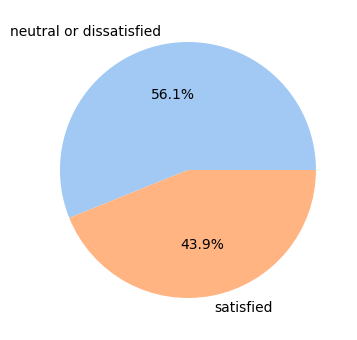

In [44]:
satisfaction_count = airline_survey_test['satisfaction'].value_counts()
satisfaction_label = satisfaction_count.index
plt.pie(satisfaction_count, labels=satisfaction_label, autopct='%.1f%%')
plt.show()

实际测试数据中，满意乘客约占43.9%。

由于逻辑回归模型不允许数据中有缺失值，因此我们需要检查`airline_survey_test`是否存在数据缺失。

In [45]:
airline_survey_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25976 entries, 0 to 25975
Data columns (total 25 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Unnamed: 0                         25976 non-null  int64  
 1   id                                 25976 non-null  int64  
 2   Gender                             25976 non-null  object 
 3   Customer Type                      25976 non-null  object 
 4   Age                                25976 non-null  int64  
 5   Type of Travel                     25976 non-null  object 
 6   Class                              25976 non-null  object 
 7   Flight Distance                    25976 non-null  int64  
 8   Inflight wifi service              25976 non-null  int64  
 9   Departure/Arrival time convenient  25976 non-null  int64  
 10  Ease of Online booking             25976 non-null  int64  
 11  Gate location                      25976 non-null  int

从以上输出可见，同样也是`Arrival Delay in Minutes`存在缺失值。需要我们进行和针对`cleaned_airline_survey_test_train`同样的操作，即用平均值填充。

In [46]:
airline_survey_test['Arrival Delay in Minutes'] = airline_survey_test['Arrival Delay in Minutes'].fillna(airline_survey_test['Arrival Delay in Minutes'].mean())
airline_survey_test['Arrival Delay in Minutes'].isna().sum()

np.int64(0)

下一步是给模型中的分类变量引入虚拟变量，但在引入前我们需要先把分类变量的类型转换为Category，并且通过`categories`参数，让程序知道所有可能的分类值。这样做的原因是，预测数据包含的分类可能不全。我们需要确保引入虚拟变量的时候，不会漏掉某个或某些分类。

In [47]:
airline_survey_test['Customer Type'] = pd.Categorical(airline_survey_test['Customer Type'], categories=['Loyal Customer', 'disloyal Customer'])
airline_survey_test['Type of Travel'] = pd.Categorical(airline_survey_test['Type of Travel'], categories=['Business travel', 'Personal Travel'])
airline_survey_test['Class'] = pd.Categorical(airline_survey_test['Class'], categories=['Business', 'Eco', 'Eco Plus'])
airline_survey_test['satisfaction'] = pd.Categorical(airline_survey_test['satisfaction'], categories=['neutral or dissatisfied', 'satisfied'])

In [48]:
airline_survey_test.head()

,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,19556,Female,Loyal Customer,52,Business travel,Eco,160,5,4,...,5,5,5,5,2,5,5,50,44.0,satisfied
1,1,90035,Female,Loyal Customer,36,Business travel,Business,2863,1,1,...,4,4,4,4,3,4,5,0,0.0,satisfied
2,2,12360,Male,disloyal Customer,20,Business travel,Eco,192,2,0,...,2,4,1,3,2,2,2,0,0.0,neutral or dissatisfied
3,3,77959,Male,Loyal Customer,44,Business travel,Business,3377,0,0,...,1,1,1,1,3,1,4,0,6.0,satisfied
4,4,36875,Female,Loyal Customer,49,Business travel,Eco,1182,2,3,...,2,2,2,2,4,2,4,0,20.0,satisfied


下一步，删除不需要的变量。

In [49]:
airline_survey_test = airline_survey_test.drop(['Unnamed: 0', 'id', 'Gender', 'Flight Distance'], axis=1)
airline_survey_test.head()

,Customer Type,Age,Type of Travel,Class,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,Loyal Customer,52,Business travel,Eco,5,4,3,4,3,4,...,5,5,5,5,2,5,5,50,44.0,satisfied
1,Loyal Customer,36,Business travel,Business,1,1,3,1,5,4,...,4,4,4,4,3,4,5,0,0.0,satisfied
2,disloyal Customer,20,Business travel,Eco,2,0,2,4,2,2,...,2,4,1,3,2,2,2,0,0.0,neutral or dissatisfied
3,Loyal Customer,44,Business travel,Business,0,0,0,2,3,4,...,1,1,1,1,3,1,4,0,6.0,satisfied
4,Loyal Customer,49,Business travel,Eco,2,3,4,3,4,1,...,2,2,2,2,4,2,4,0,20.0,satisfied


下一步，给模型用到的分类变量引入虚拟变量。

In [50]:
airline_survey_test = pd.get_dummies(airline_survey_test, drop_first=True, columns=['Customer Type', 'Type of Travel', 'Class', 'satisfaction'], dtype=int)
airline_survey_test.head()

,Age,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,...,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,Customer Type_disloyal Customer,Type of Travel_Personal Travel,Class_Eco,Class_Eco Plus,satisfaction_satisfied
0,52,5,4,3,4,3,4,3,5,5,...,2,5,5,50,44.0,0,0,1,0,1
1,36,1,1,3,1,5,4,5,4,4,...,3,4,5,0,0.0,0,0,0,0,1
2,20,2,0,2,4,2,2,2,2,4,...,2,2,2,0,0.0,1,0,1,0,0
3,44,0,0,0,2,3,4,4,1,1,...,3,1,4,0,6.0,0,0,0,0,1
4,49,2,3,4,3,4,1,2,2,2,...,4,2,4,0,20.0,0,0,1,0,1


查看一下模型需要的输入变量。

In [51]:
model.params

const                               -5.842004
Age                                 -0.008224
Inflight wifi service                0.396175
Departure/Arrival time convenient   -0.125193
Ease of Online booking              -0.142930
Gate location                        0.029248
Food and drink                      -0.026647
Online boarding                      0.611219
Seat comfort                         0.065993
Inflight entertainment               0.062765
On-board service                     0.300957
Leg room service                     0.252703
Baggage handling                     0.134870
Checkin service                      0.323739
Inflight service                     0.120701
Cleanliness                          0.223980
Departure Delay in Minutes           0.004225
Arrival Delay in Minutes            -0.008906
Customer Type_disloyal Customer     -2.026288
Type of Travel_Personal Travel      -2.715747
Class_Eco                           -0.724969
Class_Eco Plus                    

接下来构建我们要输入给模型进行预测的变量，需要和模型训练时的输入一致。

In [52]:
X_test = airline_survey_test[['Age', 'Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking', 'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort', 'Inflight entertainment', 'On-board service', 'Leg room service', 'Baggage handling', 'Checkin service', 'Inflight service', 'Cleanliness', 'Departure Delay in Minutes', 'Arrival Delay in Minutes', 'Customer Type_disloyal Customer', 'Type of Travel_Personal Travel', 'Class_Eco', 'Class_Eco Plus']]
X_test = sm.add_constant(X_test)

In [53]:
X_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25976 entries, 0 to 25975
Data columns (total 22 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   const                              25976 non-null  float64
 1   Age                                25976 non-null  int64  
 2   Inflight wifi service              25976 non-null  int64  
 3   Departure/Arrival time convenient  25976 non-null  int64  
 4   Ease of Online booking             25976 non-null  int64  
 5   Gate location                      25976 non-null  int64  
 6   Food and drink                     25976 non-null  int64  
 7   Online boarding                    25976 non-null  int64  
 8   Seat comfort                       25976 non-null  int64  
 9   Inflight entertainment             25976 non-null  int64  
 10  On-board service                   25976 non-null  int64  
 11  Leg room service                   25976 non-null  int

现在就可以调用逻辑回归模型的`predict`方法，获得预测的乘客满意概率。

In [54]:
predicted_value = model.predict(X_test)
predicted_value

0        0.936037
1        0.875891
2        0.029040
3        0.303485
4        0.066373
           ...   
25971    0.320764
25972    0.976135
25973    0.032720
25974    0.904226
25975    0.001253
Length: 25976, dtype: float64

我们获得了逻辑回归模型预测的`airline_survey_test.csv`里，乘客的满意概率。我们可以把概率大于等于0.5的预测为满意，小于0.5的预测为中立或不满意，输出一下这个最终的预测结果。

In [55]:
predicted_value > 0.5

0         True
1         True
2        False
3        False
4        False
         ...  
25971    False
25972     True
25973    False
25974     True
25975    False
Length: 25976, dtype: bool

打印出在这25976个乘客中预测满意的乘客数量。

In [56]:
print((predicted_value > 0.5).value_counts())

False    15039
True     10937
Name: count, dtype: int64


即在25976个乘客中，预测大约有10937个乘客会满意，满意乘客约占42.1%。实际测试数据中，满意乘客约占43.9%。

两者结果接近，说明本项目用逻辑回归预测的某航空公司乘客满意度情况具有较高的准确性。